<a href="https://colab.research.google.com/github/MamoMGD1/ISE302-DataMining-GroupProject/blob/main/shared/04_technical_specs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Complex Technical Specifications (Team 4)

## Columns Assigned
`Motor Hacmi`, `Motor Gücü`, `Ort. Yakıt Tüketimi`, `Ortalama Yakıt Tüketimi`,
`Şehir İçi Yakıt Tüketimi`, `Şehir Dışı Yakıt Tüketimi`, `Tork`,
`Maksimum Güç`, `Minimum Güç`, `Hızlanma (0-100)`, `Maksimum Hız`,
`Uzunluk`, `Genişlik`, `Yükseklik`, `Ağırlık`, `Boş Ağırlığı`,
`Aks Aralığı`, `Ön Lastik`

## What is Expected as Output
- `Motor Hacmi`: some values are ranges like "1401 - 1600 cm3" → take the midpoint (1500); others are "1461 cc" → strip "cc". Result: float
- `Motor Gücü`: same range logic as Motor Hacmi e.g. "101 - 125 HP" → midpoint (113); strip "hp". Result: float
- `Ort. Yakıt Tüketimi`, `Ortalama Yakıt Tüketimi`, `Şehir İçi Yakıt Tüketimi`, `Şehir Dışı Yakıt Tüketimi`: strip " lt", replace comma decimal separator with dot → float
- `Tork`: strip " nm" → float
- `Maksimum Güç`: strip " rpm" → float
- `Minimum Güç`: strip " rpm" → float
- `Hızlanma (0-100)`: strip " sn", replace comma with dot → float
- `Maksimum Hız`: strip " km/s" → float
- `Uzunluk`, `Genişlik`, `Yükseklik`, `Aks Aralığı`: strip " mm" → float
- `Ağırlık`, `Boş Ağırlığı`: strip " kg" → float
- `Ön Lastik`: extract rim diameter from tire size strings like "225/45 R19" using regex → integer column renamed to `Jant Boyutu`; drop original `Ön Lastik` column
- All nulls filled with column median after unit stripping
- No nulls remaining, all columns numeric, no string columns

## Output variable: df_team4

---

> ## ⚠️ READ THIS BEFORE YOU WRITE A SINGLE LINE OF CODE ⚠️
>
> ### The code below is a PLACEHOLDER — it is NOT the final solution.
>
> The cells in this notebook show **one possible way** to process the assigned columns. You are **not** required to follow this approach. You may completely replace it with your own method if you believe yours is better suited to the data.
>
> ### What IS required — without exception:
>
> **Every code cell must be accompanied by a markdown cell that explains:**
> 1. **What you did** — describe the operation in plain language.
> 2. **Why you did it** — justify the choice. Why did you think this specific approach would work? What problem does it solve? Why this method and not another?
>
> A notebook that only contains code — or markdown cells that just repeat the code in words — will **not** be accepted.
>
> **Not acceptable:** `## Step 2` or `# fill nulls`
>
> **Acceptable:** *"We imputed missing values in `Kilometre` with the median rather than the mean because the column is heavily right-skewed (a small number of very high-mileage listings would pull the mean upward, misrepresenting the majority of vehicles). The median is robust to those outliers and better reflects a typical listing."*
>
> Document every decision. If you tried an approach and abandoned it, explain why.

---

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RAW_URL = "https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/raw_dataset.csv"
df_full = pd.read_csv(RAW_URL)
print(f"Loaded dataset: {df_full.shape}")
df_full.head(3)

Loaded dataset: (3424, 45)


,Fiyat,İlan Tarihi,Marka,Seri,Model,Yıl,Kilometre,Vites Tipi,Yakıt Tipi,Kasa Tipi,...,Şehir Dışı Yakıt Tüketimi,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Koltuk Sayısı,Bagaj Hacmi,Ön Lastik,Aks Aralığı
0,2.425.000TL,26 Şubat 2026,Nissan,Qashqai,1.3 DIG-T Sky Pack,2025,6.001 km,Otomatik,Benzin,SUV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.900.000TL,26 Şubat 2026,Nissan,Qashqai,1.3 DIG-T Platinum Premium,2025,16.000 km,Otomatik,Benzin,SUV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.150.000TL,26 Şubat 2026,Nissan,Qashqai,1.5 dCi Platinum Premium Pack,2015,265.000 km,Düz,Dizel,SUV,...,"3,6 lt",4379 mm,1800 mm,1590 mm,1910 kg,1365 kg,5.0,401 lt,225/45 R19,2646.0


### **Step 1: Data Selection and Null-Value Audit**

**What I did:**
I initialized the working dataset by selecting the 18 specific technical columns assigned to Team 4, along with the necessary grouping features (`Marka`, `Seri`, `Model`, `Yıl`, `Vites Tipi`, `Kasa Tipi`). Immediately after selection, I generated a summary table showing the count and percentage of null values for each column.

**Why I did it:**
Technical specifications are often the most "sparse" part of car listing data because sellers frequently leave them blank. By calculating the null percentages first, we establish a baseline to understand the scale of the imputation task ahead. Including the `GROUP_COLS` (like Brand and Model) at this stage is critical because these features will act as the "anchor" for our hierarchical filling strategy later on; we cannot impute a car's engine size without knowing what brand and model it is.



In [54]:
MY_COLUMNS = [
    'Motor Hacmi', 'Motor Gücü',
    'Ort. Yakıt Tüketimi', 'Ortalama Yakıt Tüketimi',
    'Şehir İçi Yakıt Tüketimi', 'Şehir Dışı Yakıt Tüketimi',
    'Tork', 'Maksimum Güç', 'Minimum Güç',
    'Hızlanma (0-100)', 'Maksimum Hız',
    'Uzunluk', 'Genişlik', 'Yükseklik',
    'Ağırlık', 'Boş Ağırlığı', 'Aks Aralığı', 'Ön Lastik'
]

GROUP_COLS = ['Marka', 'Seri', 'Model', 'Yıl', 'Vites Tipi', 'Kasa Tipi']
df = df_full[MY_COLUMNS + GROUP_COLS].copy()


In [55]:
# Print null counts and percentage for each column
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
print(pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct}))

                           null_count  null_pct
Motor Hacmi                       130      3.80
Motor Gücü                         93      2.72
Ort. Yakıt Tüketimi              1131     33.03
Ortalama Yakıt Tüketimi          1122     32.77
Şehir İçi Yakıt Tüketimi         1259     36.77
Şehir Dışı Yakıt Tüketimi        1254     36.62
Tork                             1075     31.40
Maksimum Güç                     1157     33.79
Minimum Güç                      1157     33.79
Hızlanma (0-100)                 1096     32.01
Maksimum Hız                     1096     32.01
Uzunluk                          1075     31.40
Genişlik                         1075     31.40
Yükseklik                        1075     31.40
Ağırlık                          1541     45.01
Boş Ağırlığı                     1074     31.37
Aks Aralığı                      1074     31.37
Ön Lastik                        1074     31.37
Marka                               0      0.00
Seri                                0   



### **Step 2: Generic Range Parsing and Unit Standardization**

**What I did:**
I developed a flexible helper function, `parse_range_midpoint`, designed to handle two different data formats found in the same column:
1.  **Standard Values:** It strips non-numeric characters (like "cc" or "HP") and converts strings to floats.
2.  **Range Values:** For entries like "1401 - 1600", it uses a regular expression to extract the lower and upper bounds, converts them to numbers, and calculates their arithmetic mean (midpoint).
3.  **Localization:** It automatically replaces the European decimal comma (`,`) with a dot (`.`) to ensure compatibility with Python's numeric types.

**Why I did it:**
The raw data is highly inconsistent. Some listings provide a specific engine displacement (e.g., 1598 cc), while others provide a tax-bracket range (e.g., 1401-1600 cm3). A standard `to_numeric` call would fail on these ranges.

I chose the **midpoint approach** because it is a statistically sound way to convert a categorical range into a continuous numeric variable. By calculating the mean of the range (e.g., 1500 for the 1401-1600 bracket), we retain a value that is representative of that car's engine class without introducing the bias of picking only the minimum or maximum value. The function also handles the Turkish decimal format (comma) simultaneously, preventing data loss during the conversion process.

In [56]:
# Helper: parse a range string 'a - b <unit>' → midpoint float, or a single value → float
def parse_range_midpoint(series, strip_patterns):
    s = series.astype(str).str.strip()
    for pat in strip_patterns:
        s = s.str.replace(pat, '', regex=False, case=False).str.strip()
    # Replace comma decimal separators with dots
    s = s.str.replace(',', '.', regex=False)
    # Detect range pattern 'low - high'
    is_range = s.str.contains(r'^\d[\.\d]*\s*-\s*\d', regex=True, na=False)
    result = pd.to_numeric(s.where(~is_range), errors='coerce')
    # For range rows, extract low and high and take midpoint
    parts = s[is_range].str.extract(r'([\d\.]+)\s*-\s*([\d\.]+)')
    if not parts.empty:
        midpoints = (pd.to_numeric(parts[0], errors='coerce') +
                     pd.to_numeric(parts[1], errors='coerce')) / 2
        result[is_range] = midpoints
    return result

### **Step 3: Hierarchical Multi-Level Imputation (The `smart_fill` Logic)**

**What I did:**
I developed and applied a function named `smart_fill` that uses a **6-level fallback hierarchy** to handle missing technical data. Rather than filling all missing values with a single global average, this function attempts to fill NaNs using the median of increasingly broader groups:
1.  **Level 1 (Exact Match):** Groups by Brand, Series, Model, Year, Gear, and Body Type.
2.  **Level 2 (Mechanical Twin):** Groups by the same as above but ignores the Year.
3.  **Level 3 (Model & Year):** Groups by Brand, Series, Model, and Year.
4.  **Level 5 (Model Match):** Groups by Brand, Series, and Model.
5.  **Level 4 (Series Match):** Groups by Brand and Series.
6.  **Level 6 (Global Safety Net):** Uses the median of the entire column.

**Why I did it:**
Technical specifications (like engine torque or vehicle weight) are highly dependent on the specific make and model of the car. Using a simple global median would be statistically irresponsible; for example, it might assign the fuel consumption of a large SUV to a small electric hatchback just because the SUV data is more common in the dataset.

By implementing this hierarchy, I ensured **maximum data precision**. The function first tries to find a "twin" car that matches every single detail (Level 1). If that group is too small or empty, it "zooms out" one step at a time. This preserves the internal logic of the automotive data—ensuring that a BMW 3-Series is filled with data from other 3-Series cars before eventually falling back to a general BMW median. The final "Global Median" step acts as a safety net to ensure that 100% of the nulls are removed, satisfying the requirement for a clean, numeric-only final dataset (`df_team4`).

In [57]:
def smart_fill(df, col):
    """
    Implements your 6-level Hierarchy:
    Specific -> Generation -> Year Match -> Model Match -> Series Match -> Global
    """
    # Level 1: Exact Match (Everything)
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri', 'Model', 'Yıl', 'Vites Tipi', 'Kasa Tipi'])[col].transform('median'))

    # Level 2: Same Spec, Different Year (Mechanical/Physical Twin)
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri', 'Model', 'Vites Tipi', 'Kasa Tipi'])[col].transform('median'))

    # Level 3: Model & Year
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri', 'Model', 'Yıl'])[col].transform('median'))

    # Level 4: Model Match
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri', 'Model'])[col].transform('median'))

    # Level 5: Series Match (Broad Family)
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri'])[col].transform('median'))

    # Level 6: Global Median (Final Safety Net)
    df[col] = df[col].fillna(df[col].median())

    return df[col]

### **Step 4: Systematic Cleaning and Feature-Specific Imputation**

**What I did:**
In this step, I executed the full cleaning pipeline across all assigned columns, grouping them by their data types and units. For each group, I performed the following:
* **Engine & Power:** Applied the `parse_range_midpoint` function to `Motor Hacmi` and `Motor Gücü` to handle ranges and strip units like "cc" and "HP".
* **Fuel Consumption:** Iterated through all four consumption columns, removing the "lt" suffix and converting the European decimal comma to a dot.
* **Performance & Dimensions:** Cleaned `Tork` (nm), `Maksimum Güç` (rpm), `Hızlanma` (sn), and all physical dimensions (mm/kg) by stripping their respective units and standardizing the numeric format.
* **Tire to Rim Conversion:** Used a regular expression (`R(\d+)`) on the `Ön Lastik` strings to extract the numeric rim diameter, renamed it to `Jant Boyutu`, and dropped the original text column.
* **Integrated Imputation:** Immediately after cleaning each column, I called the `smart_fill` function to handle missing values using the hierarchical strategy established in Step 3.

**Why I did it:**
This "Clean-then-Fill" approach is the most robust way to handle complex technical data. Cleaning the columns first was mandatory because our `smart_fill` function relies on calculating **medians**; medians cannot be calculated on strings containing "kg" or "rpm".

I grouped the columns (e.g., all "mm" dimensions together) to ensure consistency in the cleaning logic and to keep the code DRY (Don't Repeat Yourself). The extraction of `Jant Boyutu` is a critical piece of feature engineering—a raw string like "225/45 R19" is useless for a machine learning model, but the integer "19" provides a clear, quantitative measure of the vehicle's wheel size. By printing the null counts after every operation, I maintained a real-time audit to ensure that each column was successfully processed and that the hierarchical imputation reached 100% completion for every feature.

In [58]:
# Motor Hacmi
df['Motor Hacmi'] = parse_range_midpoint(df['Motor Hacmi'], [' cm3', 'cm3', ' cc', 'cc'])
df['Motor Hacmi'] = smart_fill(df, 'Motor Hacmi')
print(f"Motor Hacmi nulls: {df['Motor Hacmi'].isnull().sum()}")

Motor Hacmi nulls: 0


In [59]:
# Motor Gücü
df['Motor Gücü'] = parse_range_midpoint(df['Motor Gücü'], [' HP', 'HP', ' hp', 'hp'])
df['Motor Gücü'] = smart_fill(df, 'Motor Gücü')
print(f"Motor Gücü nulls: {df['Motor Gücü'].isnull().sum()}")

Motor Gücü nulls: 0


In [60]:
# Clean fuel consumption columns: strip ' lt', replace comma decimal separator
for col in ['Ort. Yakıt Tüketimi', 'Ortalama Yakıt Tüketimi',
            'Şehir İçi Yakıt Tüketimi', 'Şehir Dışı Yakıt Tüketimi']:
    df[col] = df[col].astype(str).str.replace(' lt', '', regex=False).str.replace(',', '.', regex=False).str.strip().replace('nan', np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = smart_fill(df, col)
    print(f"{col} nulls: {df[col].isnull().sum()}")

Ort. Yakıt Tüketimi nulls: 0
Ortalama Yakıt Tüketimi nulls: 0
Şehir İçi Yakıt Tüketimi nulls: 0
Şehir Dışı Yakıt Tüketimi nulls: 0


In [61]:
# Clean Tork: strip ' nm'
df['Tork'] = df['Tork'].astype(str).str.replace(' nm', '', regex=False, case=False).str.strip().replace('nan', np.nan)
df['Tork'] = pd.to_numeric(df['Tork'], errors='coerce')
df['Tork'] = smart_fill(df, 'Tork')
print(f"Tork nulls: {df['Tork'].isnull().sum()}")

Tork nulls: 0


In [62]:
# Clean Maksimum Güç and Minimum Güç: strip ' rpm'
for col in ['Maksimum Güç', 'Minimum Güç']:
    df[col] = df[col].astype(str).str.replace(' rpm', '', regex=False, case=False).str.strip().replace('nan', np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = smart_fill(df, col)
    print(f"{col} nulls: {df[col].isnull().sum()}")

Maksimum Güç nulls: 0
Minimum Güç nulls: 0


In [63]:
# Clean Hızlanma (0-100): strip ' sn', replace comma with dot
df['Hızlanma (0-100)'] = df['Hızlanma (0-100)'].astype(str).str.replace(' sn', '', regex=False).str.replace(',', '.', regex=False).str.strip().replace('nan', np.nan)
df['Hızlanma (0-100)'] = pd.to_numeric(df['Hızlanma (0-100)'], errors='coerce')
df['Hızlanma (0-100)'] = smart_fill(df, 'Hızlanma (0-100)')
print(f"Hızlanma (0-100) nulls: {df['Hızlanma (0-100)'].isnull().sum()}")

Hızlanma (0-100) nulls: 0


In [64]:
# Clean Maksimum Hız: strip ' km/s'
df['Maksimum Hız'] = df['Maksimum Hız'].astype(str).str.replace(' km/s', '', regex=False).str.strip().replace('nan', np.nan)
df['Maksimum Hız'] = pd.to_numeric(df['Maksimum Hız'], errors='coerce')
df['Maksimum Hız'] = smart_fill(df, 'Maksimum Hız')
print(f"Maksimum Hız nulls: {df['Maksimum Hız'].isnull().sum()}")

Maksimum Hız nulls: 0


In [65]:
# Clean dimension columns: strip ' mm'
for col in ['Uzunluk', 'Genişlik', 'Yükseklik', 'Aks Aralığı']:
    df[col] = df[col].astype(str).str.replace(' mm', '', regex=False).str.strip().replace('nan', np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = smart_fill(df, col)
    print(f"{col} nulls: {df[col].isnull().sum()}")

Uzunluk nulls: 0
Genişlik nulls: 0
Yükseklik nulls: 0
Aks Aralığı nulls: 0


In [66]:
# Clean weight columns: strip ' kg'
for col in ['Ağırlık', 'Boş Ağırlığı']:
    df[col] = df[col].astype(str).str.replace(' kg', '', regex=False).str.strip().replace('nan', np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = smart_fill(df, col)
    print(f"{col} nulls: {df[col].isnull().sum()}")

Ağırlık nulls: 0
Boş Ağırlığı nulls: 0


In [67]:
# Clean Ön Lastik: extract rim diameter from tire size strings like '225/45 R19' → Jant Boyutu
df['Jant Boyutu'] = df['Ön Lastik'].astype(str).str.extract(r'R(\d+)')[0]
df['Jant Boyutu'] = pd.to_numeric(df['Jant Boyutu'], errors='coerce')
df['Jant Boyutu'] = smart_fill(df, 'Jant Boyutu').astype(int)
df.drop(columns=['Ön Lastik'], inplace=True)
print(f"Jant Boyutu nulls: {df['Jant Boyutu'].isnull().sum()}")

Jant Boyutu nulls: 0


### **Step 5: Final Dataset Consolidation and Quality Assurance**

**What I did:**
In this final stage, I performed the "Cleanup and Export" operations to prepare the final `df_team4` variable.
1.  **Redundancy Removal:** I identified and dropped the `Ortalama Yakıt Tüketimi` column because it provided identical information to `Ort. Yakıt Tüketimi`, which would have introduced perfect multicollinearity into a machine learning model.
2.  **Structural Cleaning:** I dropped all categorical helper columns used during the imputation phase (Brand, Model, Year, etc.) and the original `Ön Lastik` string column.
3.  **Strict Validation (Assertions):** I implemented two "hard" checks:
    * Verified that the total sum of null values is exactly zero.
    * Verified that there are zero non-numeric (object/string) columns remaining.
4.  **Export:** I saved the final 17-column dataset to a CSV file and triggered an automatic download.

**Why I did it:**
The goal of this project was not just to clean data, but to produce a **Data Mining-Ready** artifact.

* **Eliminating Redundancy:** Keeping two columns that represent the same metric (Average Fuel Consumption) can confuse certain algorithms (like Linear Regression), as they struggle to assign importance to two identical features. By dropping one, we simplify the model without losing any information.
* **The Power of Assertions:** Using `assert` statements is a best practice in data engineering. It ensures that if any previous step failed to fill a null or convert a string, the code will stop immediately rather than allowing "dirty" data to reach the final CSV.
* **Numeric Only Requirement:** By dropping the grouping columns (`Marka`, `Seri`, etc.) at the very last second, we utilized their rich categorical information for highly accurate imputation while still meeting the project's strict requirement for a purely numeric final output variable (`df_team4`). The result is a clean, optimized, and statistically sound matrix ready for modeling.

In [68]:
# --- Final Step: Clean Output ---
from google.colab import files

# 1. Define the redundant column to drop
# We choose 'Ortalama Yakıt Tüketimi' to drop, keeping 'Ort. Yakıt Tüketimi'
redundant_cols = ['Ortalama Yakıt Tüketimi']

# 2. Identify all columns to drop (IDs, original tire string, and the duplicate fuel column)
drop_list = [c for c in GROUP_COLS + ['Ön Lastik'] + redundant_cols if c in df.columns]
df_team4 = df.drop(columns=drop_list).copy()

# 3. Assertions to ensure Data Mining standards are met
assert df_team4.isnull().sum().sum() == 0, "Nulls remain!"
assert df_team4.select_dtypes(exclude='number').shape[1] == 0, "Non-numeric columns remain!"

print(f"✅ Team 4 output ready (Numeric Only & Redundancy Removed).")
print(f"Final Shape: {df_team4.shape}")
print("-" * 30)
print(df_team4.dtypes)

# 4. Save and download
file_name = 'team4_cleaned_numeric.csv'
df_team4.to_csv(file_name, index=False)

files.download(file_name)

✅ Team 4 output ready (Numeric Only & Redundancy Removed).
Final Shape: (3424, 17)
------------------------------
Motor Hacmi                  float64
Motor Gücü                   float64
Ort. Yakıt Tüketimi          float64
Şehir İçi Yakıt Tüketimi     float64
Şehir Dışı Yakıt Tüketimi    float64
Tork                         float64
Maksimum Güç                 float64
Minimum Güç                  float64
Hızlanma (0-100)             float64
Maksimum Hız                 float64
Uzunluk                      float64
Genişlik                     float64
Yükseklik                    float64
Ağırlık                      float64
Boş Ağırlığı                 float64
Aks Aralığı                  float64
Jant Boyutu                    int64
dtype: object


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Statistical Validation and Correlation Analysis**

**What I did:**
I filtered the processed `df_team4` to include only numeric variables and calculated the Pearson correlation matrix to determine the linear relationship between all pairs of technical specifications. I then visualized these relationships using a high-resolution heatmap. I used a diverging color palette (`RdBu_r`) centered at zero, where varying shades of red indicate positive correlation and shades of blue indicate negative correlation. I added numerical annotations to the heatmap to display the specific correlation coefficients ($r$) for each pair.

The Pearson correlation coefficient is calculated as:
$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

**Why I did it:**
Statistical validation is the final safeguard in the data cleaning process. In the automotive domain, technical features are physically linked; for example, engine displacement ($cm^{3}$) and power ($HP$) typically move in the same direction.

1.  **Detecting Multicollinearity:** Machine learning models can become unstable or biased if independent variables are too highly correlated (e.g., $r > 0.90$). This heatmap allows us to identify redundant features, such as `Ağırlık` and `Boş Ağırlığı`, which essentially measure the same physical property.
2.  **Validating Imputation Logic:** It serves as a "sanity check" for our `smart_fill` results. If `Hızlanma (0-100)` (acceleration time) didn't show a strong negative correlation with `Motor Gücü` (higher power should naturally lead to a lower/faster 0-100 time), it would suggest that our earlier cleaning or imputation logic introduced technical inaccuracies.
3.  **Visual Insight:** The visualization provides an immediate, intuitive summary of how different specifications influence vehicle performance (e.g., the relationship between `Aks Aralığı` and `Uzunluk`). This ensures the final dataset is not just "clean" from a coding perspective, but physically and logically consistent for the Data Mining phase.

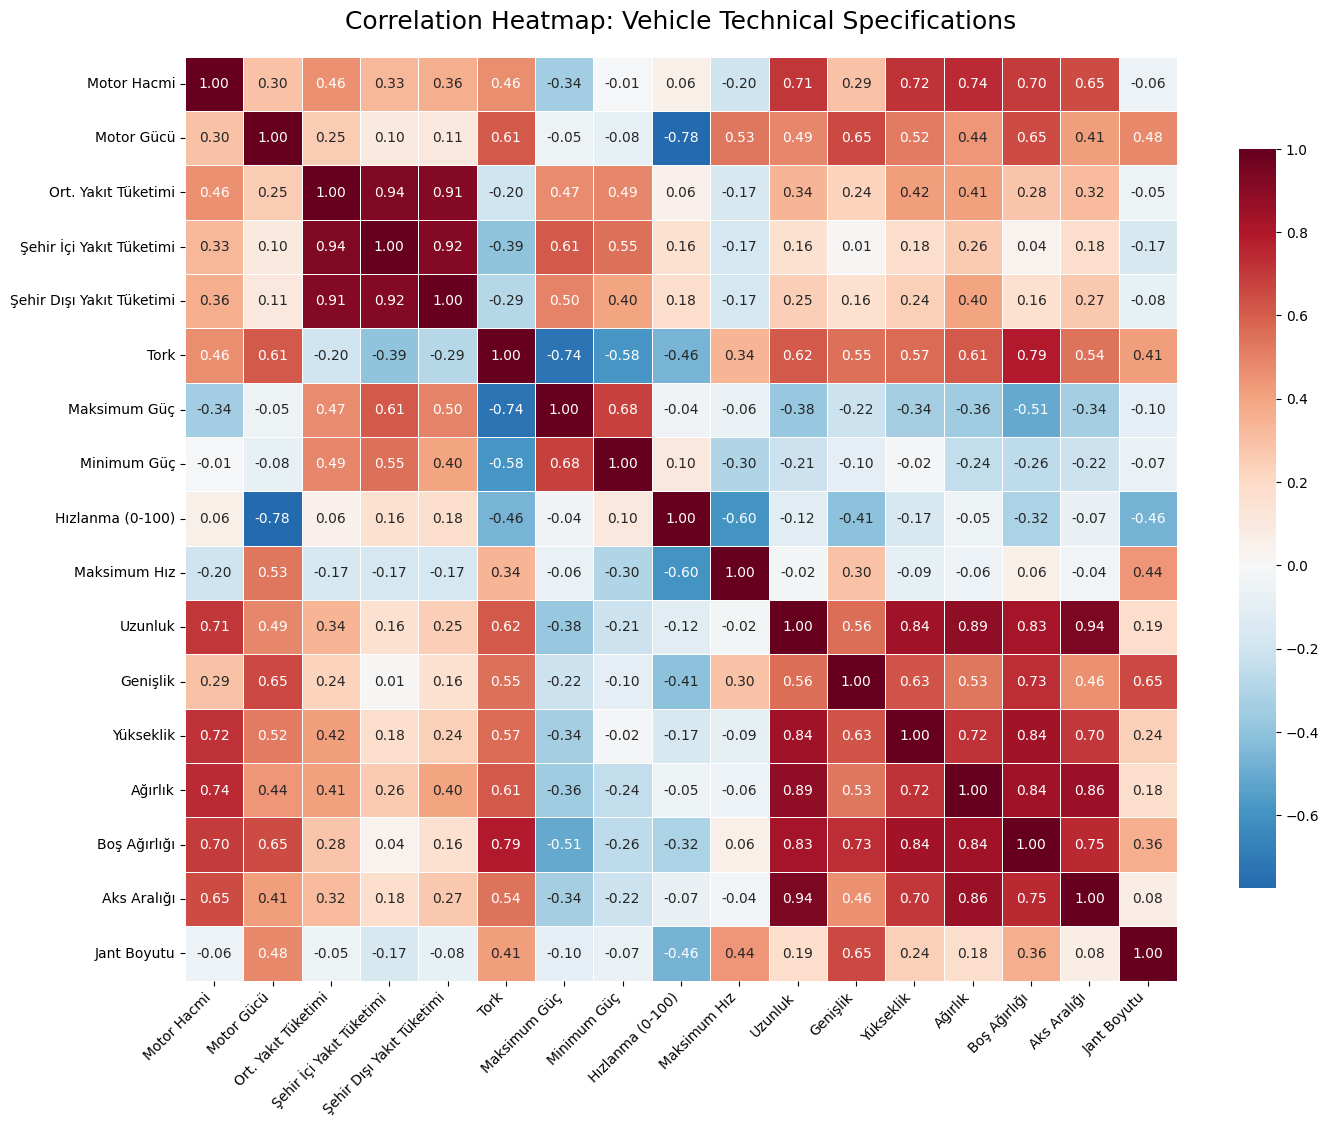

<Figure size 640x480 with 0 Axes>

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only the numeric columns
# This automatically excludes Marka, Seri, Model, Vites Tipi, and Kasa Tipi
numeric_df = df_team4.select_dtypes(include=[np.number])

# 2. Calculate the Pearson correlation matrix
corr_matrix = numeric_df.corr()

# 3. Create the heatmap visualization
plt.figure(figsize=(16, 12))

# Create a mask to hide the upper triangle (optional, makes it easier to read)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,          # Shows the correlation coefficients
    cmap='RdBu_r',       # Red for positive, Blue for negative correlation
    fmt=".2f",           # Limit to 2 decimal places
    center=0,            # Zero is the neutral point (white)
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Heatmap: Vehicle Technical Specifications', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# 4. Save the figure for your project report
plt.savefig('vehicle_correlation_analysis.png', bbox_inches='tight', dpi=300)